# Dataset Acquisition & Exploration

**Dataset Source, Justification, and Real-world Relevance**
- **Source**: The dataset was exported via Roboflow (May 10, 2026), originally containing three classes: `car`, `car_plate`, and `driver`.
- **Justification**: It provides annotated bounding boxes in YOLOv8 format which is ideal for real-time object detection models. 
- **Real-world relevance**: Detecting cars, plates, and drivers is fundamental for traffic monitoring, autonomous driving, and automated toll collection or speeding enforcement systems.

In [1]:
# Import required libraries
import os
import glob
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Define paths
dataset_dir = 'Dataset'
train_images_dir = os.path.join(dataset_dir, 'train', 'images')
train_labels_dir = os.path.join(dataset_dir, 'train', 'labels')

# Define class mapping based on data.yaml
class_names = {0: 'car', 1: 'car_plate', 2: 'driver'}

In [2]:
# 1. Total image count, class distribution, and image resolution statistics

image_files = glob.glob(os.path.join(train_images_dir, '*.jpg'))
print(f"Total number of images: {len(image_files)}")

class_counts = {c: 0 for c in class_names.values()}
resolutions = []

# Process labels and images
for img_path in image_files:
    # Get resolution
    try:
        with Image.open(img_path) as img:
            resolutions.append((img.width, img.height))
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")

    # Get class counts from label files
    basename = os.path.basename(img_path)
    label_path = os.path.join(train_labels_dir, basename.replace('.jpg', '.txt'))
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                class_id = int(line.split()[0])
                if class_id in class_names:
                    class_counts[class_names[class_id]] += 1

print("\nClass Distribution:")
for cls, count in class_counts.items():
    print(f"- {cls}: {count} instances")

widths, heights = zip(*resolutions) if resolutions else ([], [])
print(f"\nImage Resolution Statistics:")
print(f"- Average Width: {sum(widths)/len(widths):.2f} px")
print(f"- Average Height: {sum(heights)/len(heights):.2f} px")
print(f"- Min Resolution: {min(widths)}x{min(heights)}")
print(f"- Max Resolution: {max(widths)}x{max(heights)}")

Total number of images: 958

Class Distribution:
- car: 1301 instances
- car_plate: 891 instances
- driver: 741 instances

Image Resolution Statistics:
- Average Width: 632.09 px
- Average Height: 593.03 px
- Min Resolution: 332x420
- Max Resolution: 1920x1080


C:\Users\HP\AppData\Local\Temp\ipykernel_6064\2733747458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


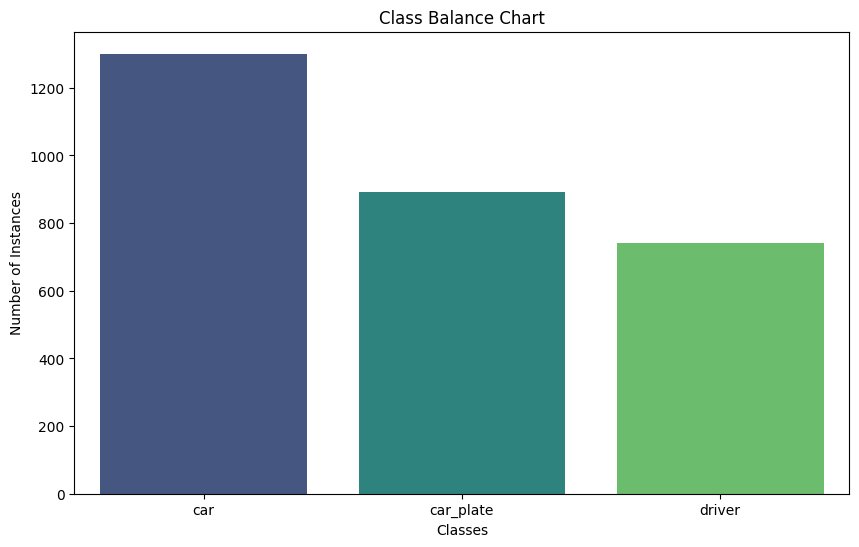

In [3]:
# Visualization 1: Class Balance Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Class Balance Chart')
plt.xlabel('Classes')
plt.ylabel('Number of Instances')
plt.show()

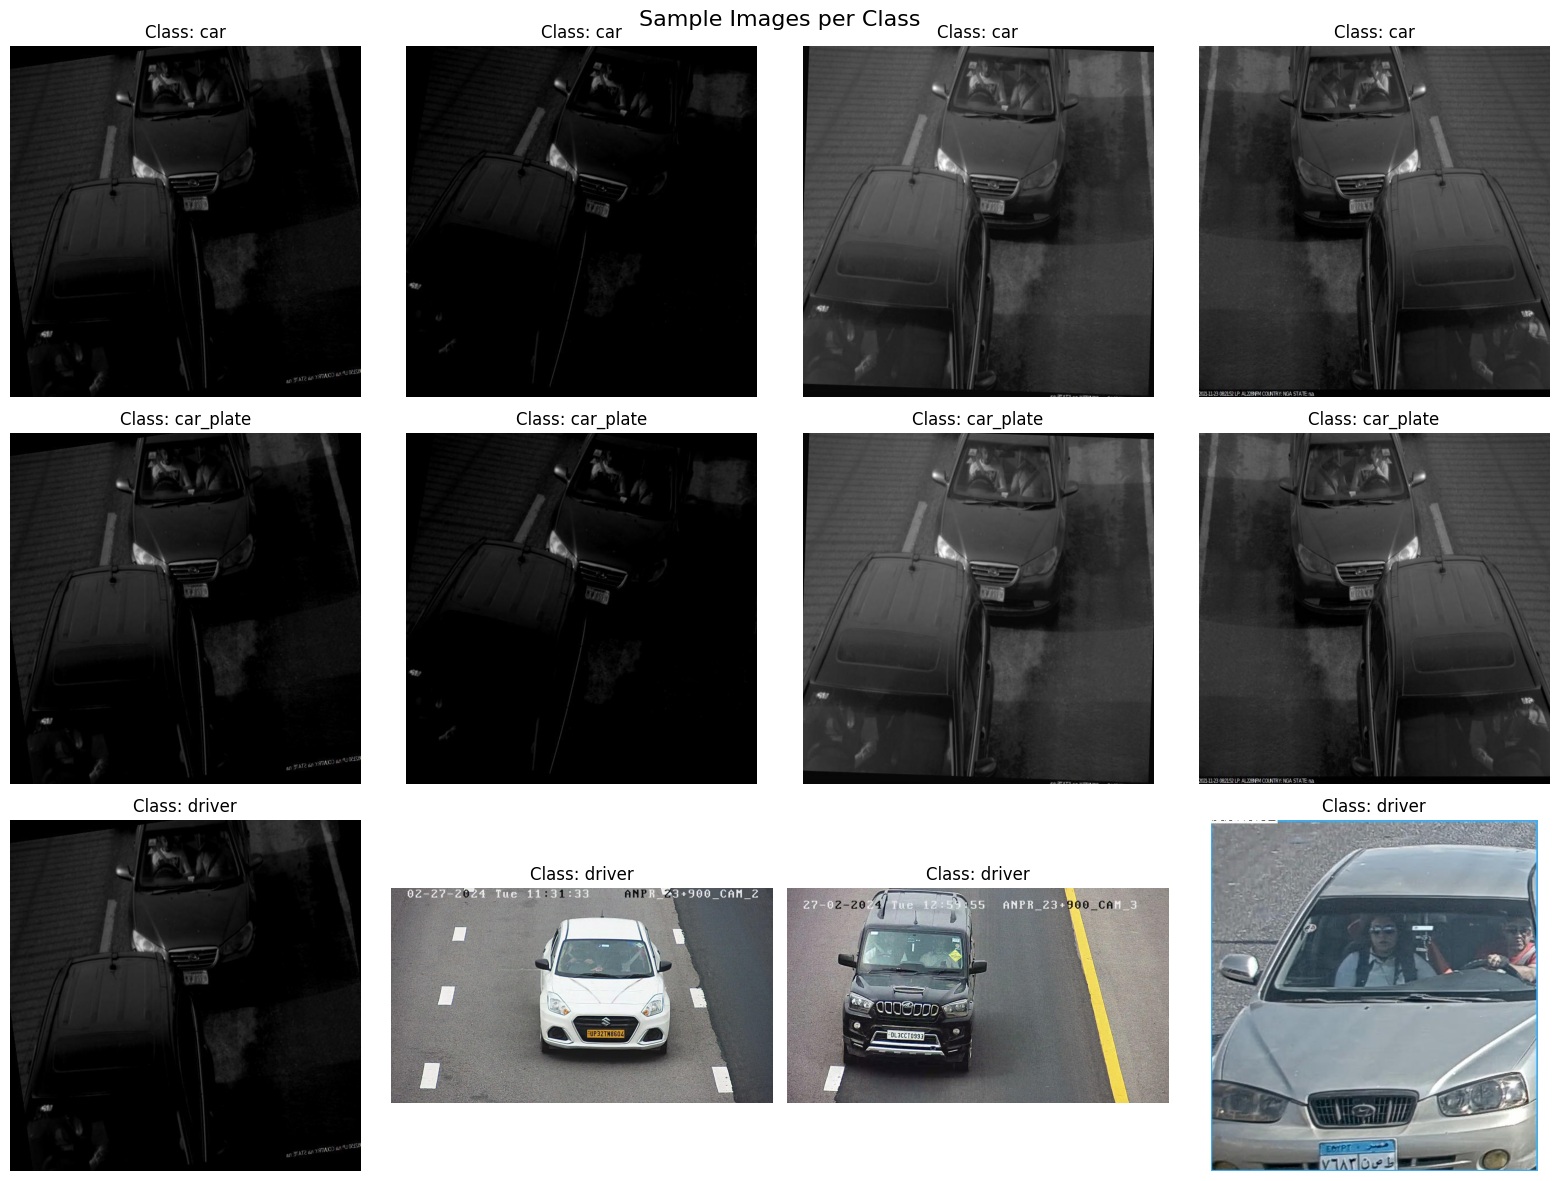

In [5]:
# Visualization 2: Sample Grid of Images per Class
# Find sample images containing each class
sample_images_per_class = {cls: [] for cls in class_names.values()}

for img_path in image_files:
    basename = os.path.basename(img_path)
    label_path = os.path.join(train_labels_dir, basename.replace('.jpg', '.txt'))
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                class_id = int(line.split()[0])
                if class_id in class_names:
                    cls_name = class_names[class_id]
                    if len(sample_images_per_class[cls_name]) < 4:
                        if img_path not in sample_images_per_class[cls_name]:
                            sample_images_per_class[cls_name].append(img_path)

fig, axes = plt.subplots(len(class_names), 4, figsize=(16, 4 * len(class_names)))
fig.suptitle('Sample Images per Class', fontsize=16)

class_idx = 0
for cls, img_paths in sample_images_per_class.items():
    for j, img_path in enumerate(img_paths):
        ax = axes[class_idx, j]
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"Class: {cls}")
            ax.axis('off')
        except Exception:
            pass
    class_idx += 1
    
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

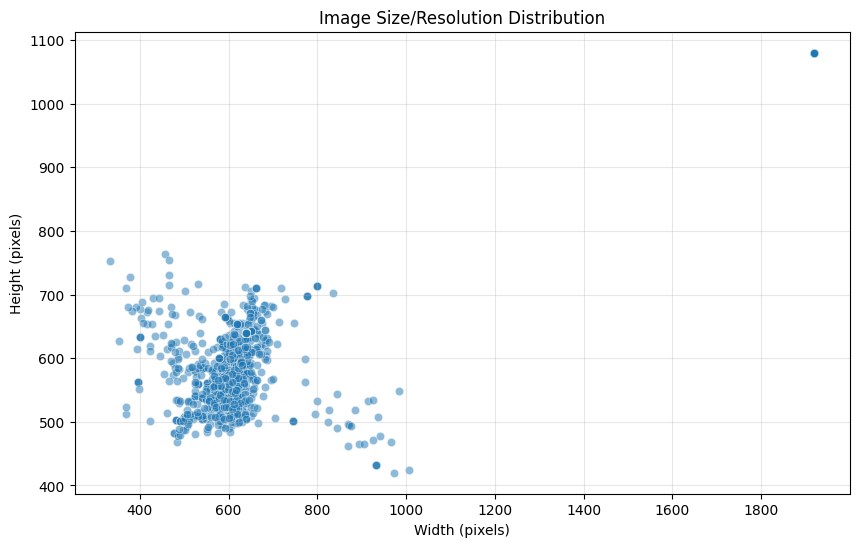

In [6]:
# Visualization 3: Image Size / Resolution Distribution
res_df = pd.DataFrame(resolutions, columns=['Width', 'Height'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=res_df, x='Width', y='Height', alpha=0.5)
plt.title('Image Size/Resolution Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True, alpha=0.3)
plt.show()

## Discussion on Class Imbalance and Data Challenges

Based on the exploration above, here are a few potential issues and observations:
1. **Class Imbalance**: Depending on what the statistics show, the number of instances for `car` could significantly outnumber `car_plate` or `driver`. A model trained on highly imbalanced data might become excessively biased towards predicting only the majority class. Techniques such as data augmentation (e.g., cropping, scaling, flipping) or adjusting loss weights could help mitigate this issue.
2. **Quality Issues**: The images might vary significantly in resolution based on the scatterplot distribution, varying lighting conditions, camera artifacts, or motion blur which are typical data challenges in outdoor surveillance and traffic monitoring systems.
3. **Occlusions and Tiny Objects**: `car_plate` and `driver` are inherently much smaller than `car` in the visual space. Object detection networks might struggle with detecting small objects or when a car's plate is partially occluded.

Data split complete! Train: 670, Val: 144, Test: 144


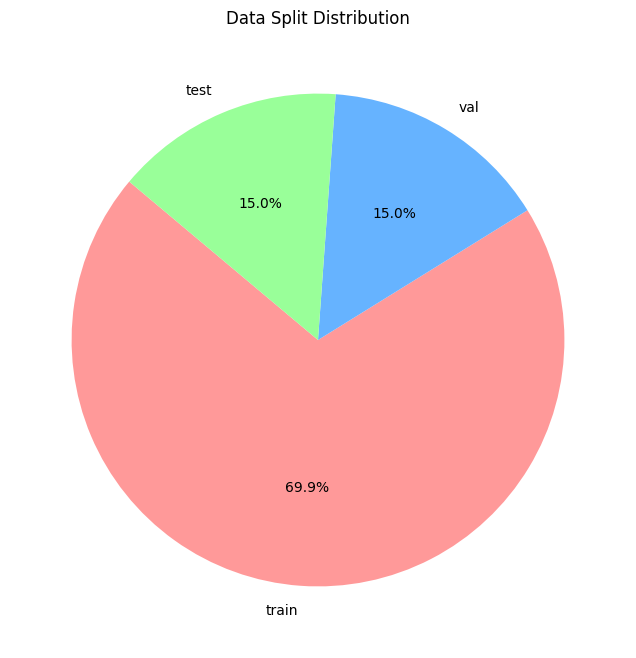

In [7]:
# Split data into train, val, test and create pie chart
import os
import shutil
import glob
import random
import matplotlib.pyplot as plt

source_images_dir = 'Dataset/train/images'
source_labels_dir = 'Dataset/train/labels'
output_dir = 'Dataset_Split'

# Get list of images
image_files = glob.glob(os.path.join(source_images_dir, '*.jpg'))
random.seed(42) # For reproducibility
random.shuffle(image_files)

# Split ratios: 70% train, 15% val, 15% test
total_images = len(image_files)
train_end = int(0.7 * total_images)
val_end = int(0.85 * total_images)

train_images = image_files[:train_end]
val_images = image_files[train_end:val_end]
test_images = image_files[val_end:]

splits = {
    'train': train_images,
    'val': val_images,
    'test': test_images
}

# Process each split
split_counts = {'train': 0, 'val': 0, 'test': 0}

for split, images in splits.items():
    for img_path in images:
        basename = os.path.basename(img_path)
        name_without_ext = os.path.splitext(basename)[0]
        
        # Source label path
        label_path = os.path.join(source_labels_dir, name_without_ext + '.txt')
        
        # Destination folder
        dest_folder = os.path.join(output_dir, split, name_without_ext)
        os.makedirs(dest_folder, exist_ok=True)
        
        # Copy image
        shutil.copy(img_path, os.path.join(dest_folder, basename))
        
        # Copy label if exists
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(dest_folder, name_without_ext + '.txt'))
            
    split_counts[split] = len(images)

print(f"Data split complete! Train: {split_counts['train']}, Val: {split_counts['val']}, Test: {split_counts['test']}")

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(split_counts.values(), labels=split_counts.keys(), autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Data Split Distribution')
plt.show()

In [10]:
# Convert polygon annotations to YOLO bounding box format across all split datasets
import os
import glob

split_dir = 'Dataset_Split'

# Get all .txt files in the split directory
label_files = glob.glob(os.path.join(split_dir, '**', '*.txt'), recursive=True)

processed_files = 0
for label_path in label_files:
    with open(label_path, 'r') as f:
        lines = f.readlines()
    
    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) > 5: # It's a polygon
            class_id = parts[0]
            coords = list(map(float, parts[1:]))
            
            # Extract X coordinates (even indices from 0 in coords list)
            x_coords = coords[0::2]
            # Extract Y coordinates (odd indices from 0 in coords list)
            y_coords = coords[1::2]
            
            min_x, max_x = min(x_coords), max(x_coords)
            min_y, max_y = min(y_coords), max(y_coords)
            
            # Calculate YOLO format
            x_center = (min_x + max_x) / 2.0
            y_center = (min_y + max_y) / 2.0
            width = max_x - min_x
            height = max_y - min_y
            
            new_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
        else:
            # Already bounding box or empty
            new_lines.append(line)
            
    # Overwrite the file with bounding box data
    with open(label_path, 'w') as f:
        f.writelines(new_lines)
    processed_files += 1

print(f"Converted {processed_files} annotation files to YOLO bounding box format.")

Converted 958 annotation files to YOLO bounding box format.


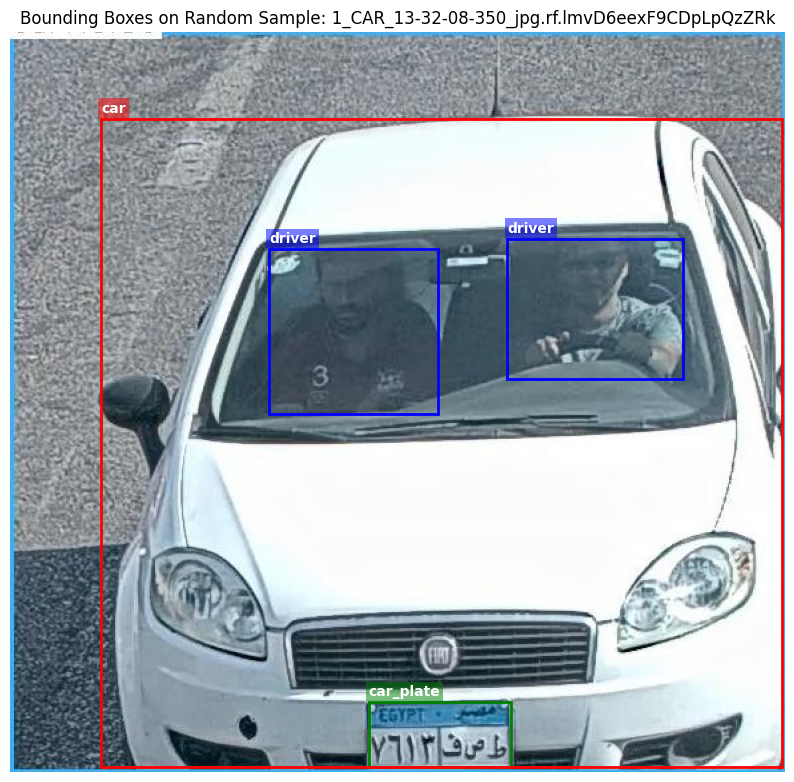

In [14]:
# Visualize bounding boxes for a random sample
import os
import random
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

split_dir = 'Dataset_Split'
# Get a list of all images in the split directory
all_images = glob.glob(os.path.join(split_dir, '**', '*.jpg'), recursive=True)

if not all_images:
    print("No images found in Dataset_Split directory.")
else:
    # Pick a random image
    img_path = random.choice(all_images)
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    
    # The label should be in the same folder as the image
    label_path = os.path.join(os.path.dirname(img_path), f"{base_name}.txt")

    # Class color definitions for visualization
    class_names = {0: 'car', 1: 'car_plate', 2: 'driver'}
    colors = {0: 'red', 1: 'green', 2: 'blue'}

    if os.path.exists(img_path) and os.path.exists(label_path):
        img = Image.open(img_path)
        img_width, img_height = img.size
        
        fig, ax = plt.subplots(1, figsize=(10, 10))
        ax.imshow(img)
        
        # Read YOLO format annotations
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                # Ensure it has been converted to bounding box format (5 elements)
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    
                    # Convert from normalized to absolute coordinates
                    abs_width = width * img_width
                    abs_height = height * img_height
                    x_min = (x_center * img_width) - (abs_width / 2)
                    y_min = (y_center * img_height) - (abs_height / 2)
                    
                    # Draw bounding box
                    color = colors.get(class_id, 'yellow')
                    class_name = class_names.get(class_id, f"Class {class_id}")
                    
                    rect = patches.Rectangle((x_min, y_min), abs_width, abs_height, 
                                             linewidth=2, edgecolor=color, facecolor='none')
                    ax.add_patch(rect)
                    
                    # Add label
                    plt.text(x_min, y_min - 5, class_name, color='white', 
                             fontsize=10, weight='bold', bbox=dict(facecolor=color, alpha=0.5, pad=2, edgecolor='none'))
                    
        plt.title(f'Bounding Boxes on Random Sample: {base_name}')
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not find the annotation file for random image: {img_path}")